In [35]:
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from tqdm import tqdm
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [ ]:
class PCAMDataset(Dataset):
    def __init__(self, x_path, y_path, indices=None, transform=None):
        self.x_path = x_path
        self.y_path = y_path
        self.transform = transform

        with h5py.File(x_path, 'r') as f:
            self.full_length = len(f['x'])

        if indices is None:
            self.indices = list(range(self.full_length))
        else:
            self.indices = indices

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]

        with h5py.File(self.x_path, 'r') as x_file, \
             h5py.File(self.y_path, 'r') as y_file:

            img = x_file['x'][idx]
            label = y_file['y'][idx][0]

        img = img.astype(np.uint8)

        if self.transform:
            img = self.transform(img)

        return img, label

In [37]:
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((96,96)),
    transforms.ToTensor(),
    transforms.Normalize([0.7,0.5,0.7], [0.2,0.2,0.2])
])

In [ ]:
train_dataset = PCAMDataset(
    "pcam/camelyonpatch_level_2_split_train_x.h5",
    "pcam/camelyonpatch_level_2_split_train_y.h5",
    train_indices,
    transform
)

val_dataset = PCAMDataset(
    "pcam/camelyonpatch_level_2_split_valid_x.h5",
    "pcam/camelyonpatch_level_2_split_valid_y.h5",
    val_indices,
    transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0 
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

print("Train:", len(train_dataset), "Val:", len(val_dataset))

Train: 5000 Val: 1000


In [39]:
class ImprovedCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),

            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.AdaptiveAvgPool2d(1)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [ ]:
def train_model(model, train_loader, val_loader, epochs=10):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[]}

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        # train
        model.train()
        train_loss, correct, total = 0, 0, 0

        for imgs, labels in tqdm(train_loader, desc="Train"):
            imgs = imgs.to(device)
            labels = labels.float().view(-1).to(device)

            outputs = model(imgs).view(-1)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            preds = (torch.sigmoid(outputs) > 0.5).int()
            correct += (preds == labels.int()).sum().item()
            total += labels.size(0)

        train_acc = correct / total

        # validation
        model.eval()
        val_loss, correct, total = 0, 0, 0

        with torch.no_grad():
            for imgs, labels in tqdm(val_loader, desc="Val"):
                imgs = imgs.to(device)
                labels = labels.float().view(-1).to(device)

                outputs = model(imgs).view(-1)
                loss = criterion(outputs, labels)

                val_loss += loss.item()

                preds = (torch.sigmoid(outputs) > 0.5).int()
                correct += (preds == labels.int()).sum().item()
                total += labels.size(0)

        val_acc = correct / total

        history["train_loss"].append(train_loss/len(train_loader))
        history["val_loss"].append(val_loss/len(val_loader))
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        print(f"Train Loss: {history['train_loss'][-1]:.4f} | Acc: {train_acc:.4f}")
        print(f"Val   Loss: {history['val_loss'][-1]:.4f} | Acc: {val_acc:.4f}")

    return history

In [41]:
def plot_training(history):
    plt.figure(figsize=(12,5))

    plt.subplot(1,2,1)
    plt.plot(history['train_loss'], label="Train")
    plt.plot(history['val_loss'], label="Val")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history['train_acc'], label="Train")
    plt.plot(history['val_acc'], label="Val")
    plt.title("Accuracy")
    plt.legend()

    plt.show()

In [42]:
def show_samples(loader):
    imgs, labels = next(iter(loader))

    plt.figure(figsize=(10,5))
    for i in range(6):
        img = imgs[i].permute(1,2,0).numpy()
        img = (img - img.min()) / (img.max() - img.min())

        plt.subplot(2,3,i+1)
        plt.imshow(img)
        plt.title(f"Label: {labels[i].item()}")
        plt.axis('off')

    plt.show()

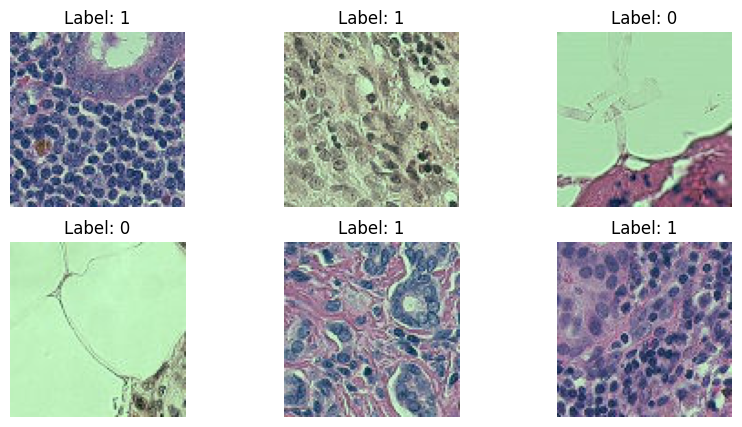


Epoch 1/10


Val: 100%|██████████| 32/32 [00:10<00:00,  3.02it/s]


Train Loss: 0.4672 | Acc: 0.7856
Val   Loss: 0.4550 | Acc: 0.7860

Epoch 2/10


Val: 100%|██████████| 32/32 [00:09<00:00,  3.24it/s]


Train Loss: 0.4266 | Acc: 0.8180
Val   Loss: 0.4360 | Acc: 0.7860

Epoch 3/10


...

Train Loss: 0.3666 | Acc: 0.8428
Val   Loss: 0.4378 | Acc: 0.8030

Epoch 9/10


Val: 100%|██████████| 32/32 [00:11<00:00,  2.75it/s]


Train Loss: 0.3585 | Acc: 0.8486
Val   Loss: 0.5080 | Acc: 0.7670

Epoch 10/10


Val: 100%|██████████| 32/32 [00:10<00:00,  2.96it/s]


Train Loss: 0.3511 | Acc: 0.8550
Val   Loss: 0.5026 | Acc: 0.7850


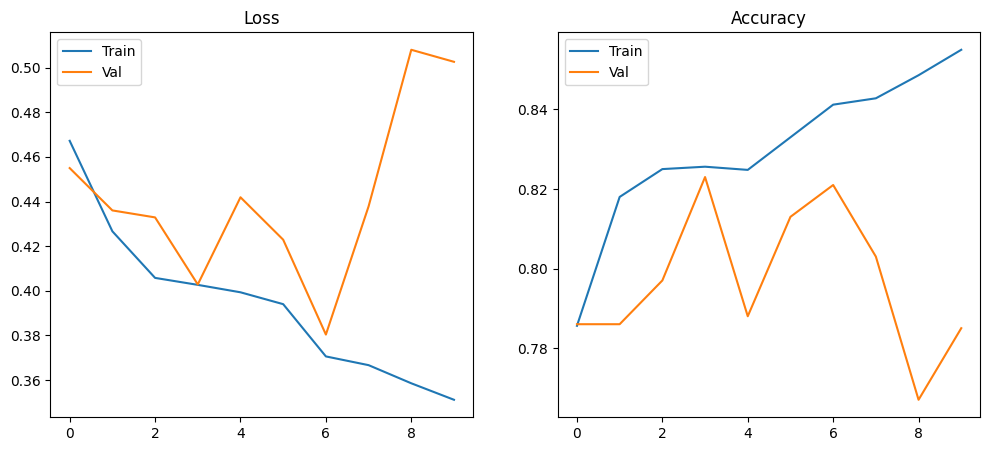

In [43]:
model = ImprovedCNN().to(device)

show_samples(train_loader)

history = train_model(model, train_loader, val_loader, epochs=10)

plot_training(history)